# USDA Cat Detection List

Includes all cats (domestic and wild)

* Put together table of all cat outbreaks/detections recorded by USDA as of current date (6/3/2025)
* Cross reference date, state, and host to find genotype from our datasets

In [1]:
# Housekeeping

import os
import pandas as pd
import seaborn as sns
import matplotlib as plt
from matplotlib import pyplot
import dateutil 
from datetime import datetime, timedelta
import importlib
import utils  
importlib.reload(utils)
from utils import * 

# home = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu/"
home = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu/"
# downloads = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/"
downloads = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/" 
originals = downloads + "Cats/cat_genotypes_11-01-2021--06-05-2025/"
# new_B3_13 = downloads + "Combinations/GISAID_Andersen_NCBI_Virus/11-01-2021--06-05-2025_B3_13/"
# new_D1_1 = downloads + "Combinations/GISAID_Andersen_NCBI_Virus/11-01-2021--06-05-2025_D1_1/"
cat_files = downloads + "Cats/"

os.chdir(home + "references/")
animals_ref = pd.read_csv("animals_ref.csv")
states_ref = pd.read_csv("states_ref.csv")

os.chdir(cat_files + "USDA/")
detections = pd.read_csv("HPAI Detections in Mammals.csv")


In [2]:
print(animals_ref["feline"])

display(detections)

0               cat
1      domestic_cat
2         feral_cat
3            feline
4      domestic-cat
           ...     
422             NaN
423             NaN
424             NaN
425             NaN
426             NaN
Name: feline, Length: 427, dtype: object


,State,County,Date Collected,Date Detected,HPAI Strain,Species
0,South Dakota,Aurora,5/6/2025,5/15/2025,EA H5,Domestic cat
1,Kansas,Kearny,1/30/2025,5/8/2025,EA H5,Bobcat
2,New York,Madison,4/23/2025,5/1/2025,EA H5,Red fox
3,New York,Onondaga,4/23/2025,5/1/2025,EA H5,Gray fox
4,Idaho,Ada,4/15/2025,4/29/2025,EA H5,Domestic cat
...,...,...,...,...,...,...
612,Wisconsin,Jefferson,4/9/2022,5/6/2022,EA H5N1,Red fox
613,Wisconsin,Jefferson,4/9/2022,5/6/2022,EA H5N1,Red fox
614,Wisconsin,Dane,5/5/2022,5/6/2022,EA H5N1,Red fox
615,Wisconsin,Rock,4/19/2022,5/5/2022,EA H5N1,Red fox


In [3]:
# Find only cats

detections["Species"] = detections["Species"].apply(str.lower)
detections["Feline"] = detections["Species"].apply(lambda x: "feline" if x in animals_ref["feline"].values else "non-feline")
detections_feline = detections[detections["Feline"] == "feline"]

print(detections_feline)

# Export as csv
# detections_feline.to_csv("USDA_feline_detections_06_03_2025.csv")

detections_feline_unique = detections_feline.drop_duplicates(keep="first")
# detections_feline_unique.to_csv("USDA_feline_detections_unique_06_03_2025.csv")

            State   County Date Collected Date Detected HPAI Strain  \
0    South Dakota   Aurora       5/6/2025     5/15/2025       EA H5   
1          Kansas   Kearny      1/30/2025      5/8/2025       EA H5   
4           Idaho      Ada      4/15/2025     4/29/2025       EA H5   
13       Colorado     Weld       4/4/2025     4/15/2025       EA H5   
20     California  Alameda     12/30/2024      4/4/2025       EA H5   
..            ...      ...            ...           ...         ...   
499      Nebraska  Madison      1/10/2023     1/13/2023     EA H5N1   
501        Oregon     Linn     12/27/2022      1/3/2023  EA/AM H5N1   
505        Oregon     Linn     12/19/2022    12/23/2022  EA/AM H5N1   
586     Wisconsin  Lincoln      4/24/2022     5/24/2022     EA H5N1   
587     Wisconsin  Lincoln       5/5/2022     5/24/2022     EA H5N1   

          Species  Feline  
0    domestic cat  feline  
1          bobcat  feline  
4    domestic cat  feline  
13   domestic cat  feline  
20   do

## Find genotypes with feline from all_genotypes dataset 4-14-2025

And concatenate with B3.13/D1.1 datasets from 6/5/2025

In [ ]:
# Prepare dataframes 



def fasta_df_og(file_name, state_ref):

    fasta = pd.DataFrame()
    headers = []
    isolate_ids = []
    isolate_names = []
    subtypes = []
    segments = []
    collection_dates = []
    sequences = []
    host_types = []
    species = []
    genotypes = []
    with open(file_name) as f:
        lines = f.readlines()
        for num, line in enumerate(lines):
            # print(line)
            if line[0] == ">": # If it's a header
                if line[1:].strip() not in headers: # And the previous line is not a header we've seen before
                    
                    header = line[1:].strip() # Remove the ">"
                    # print(header)
                    if len(header.split("|")) > 6:
                        header = header.replace(header.split("|")[0], "")[1:]
                    split_header = header.split("|")
                    split_first_header = split_header[0].split("/")
                    # print(split_first_header)
                    headers.append(header) 
                    isolate_ids.append(split_first_header[3])
                    isolate_names.append(split_header[1]) # We'll need to extract data from this too
                    # print(split_header[2].split("_")[-1])
                    subtypes.append(split_header[-4])  # Get only H5N1
                    genotypes.append(split_header[-1])
                    segments.append(file_name.split("_")[-3])
                    host_types.append(split_header[-2])
                    species.append(split_first_header[1])
                    # if split_header[4] == "2024-01-01":
                    #     collection_dates.append("2024") # No samples were collected 1/1/2024, these are all unknown 
                    # elif split_header[4] == "2025-01-01":
                    #     collection_dates.append("2025")
                    # else: 
                    collection_dates.append(split_header[-3].split("_")[-1])
                    if num < len(lines): # If we're not at the last line
                        # for i, l in enumerate(lines[num + 1:]):
                        i = num
                        sequence = ""
                        # print(lines[i])
                        # print(lines[i + 1])
                        while i < len(lines) - 1 and lines[i + 1][0] != ">": # While the next line is part of a sequence
                            sequence = sequence + lines[i + 1].strip()
                            i += 1
                        sequences.append(sequence) # Add next line to sequences
        f.close()

    # Create columns for data frame 
    fasta["Header"] = headers
    fasta["Isolate_Id"] = isolate_ids
    fasta["Isolate_Name"] = isolate_names
    fasta["Subtype"] = subtypes
    fasta["Segment"] = segments
    # Geo_Location is more complicated
    fasta["Geo_Location"] = fasta["Header"].apply(lambda x: state_ref.loc[state_ref["Abbreviation"] == x.split("/")[2], 'Country'].iloc[0] + "-" + x.split("/")[2] if x.split("/")[2] in state_ref["Abbreviation"].values else state_ref.loc[state_ref["State"] == x.split("/")[2].replace("_", " "), 'Country'].iloc[0] + "-" + state_ref.loc[state_ref["State"] == x.split("/")[2].replace("_", " "), 'Abbreviation'].iloc[0] if x.split("/")[2].replace("_", " ") in state_ref["State"].values else x.split("/")[2].replace(": ", "-"))
    fasta["Date Collected"] = collection_dates
    fasta["Species"] = species
    fasta["Host_Type"] = host_types
    fasta["Genotype"] = genotypes
    fasta["Sequence"] = sequences
    
    return fasta

# Grab files

os.chdir(originals)
cat_genotypes = set()
dfs = {}
for dirpath, dirs, files in os.walk(originals):
    for file in files:
        file_name = os.path.join(dirpath, file)
        if "PB1" in file_name and ".fasta" in file_name: # All metadata should be same
            # if "B3_13" in file_name:
            #     with open(file_name) as f:
            #         lines = f.readlines()
            #         for line in lines:
            #             if "feline" in line:
            #                 print(file_name)
            #                 cat_genotypes.add(line.split("|")[-1]) # The genotype
            #                 print(line)
            #                 # break 
            #                 file_name_fasta_df = fasta_df(file_name, states_ref)
                            
            #                 dfs[file_name] = file_name_fasta_df
            #                 # break 
            #                 # print(file_name)
            # if "D1_1" in file_name:
            #     with open(file_name) as f:
            #         lines = f.readlines()
            #         for line in lines:
            #             if "feline" in line:
            #                 print(file_name)
            #                 cat_genotypes.add(line.split("|")[-1]) # The genotype
            #                 print(line)
            #                 # break 
            #                 dfs[file_name] = fasta_df(file_name, states_ref)
            #                 # break 
            # else:
            with open(file_name) as f:
                lines = f.readlines()
                for line in lines:
                    if "feline" in line:
                        print(file_name)
                        cat_genotypes.add(line.split("|")[-1]) # The genotype
                        # print(line)
                        # break 
                        # if len(line.split("|")) > 6:
                        #     line = line.replace(line.split("|")[0])[1:]
                        #     dfs[file_name] = fasta_df_og(file_name, states_ref)
                        # else:
                        dfs[file_name] = fasta_df_og(file_name, states_ref)
                        break 

print(cat_genotypes)

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/A3_PB1_11-1-2021--6-5-2025_concat.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/B3.13_PB1_11-1-2021--6-5-2025_concat.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/B3.2_PB1_11-1-2021--6-5-2025_concat.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/B3.5_PB1_11-1-2021--6-5-2025_concat.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/B3.6_PB1_11-1-2021--6-5-2025_concat.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/B3.7_PB1_11-1-2021--6-5-2025_concat.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/D1.1_PB1_11-1-2021--6-5-2025_concat.fasta
{'A3\n', 'B3.6\n', 'B3.5\n', 'D1.1\

### Cross-reference USDA cat list with our dataset to find genotypes

Append genotypes to USDA cat list

In [ ]:
# print(dfs["C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\D1.1_PB2_combined_04-14-2025.fasta"])

# Get cats only
cat_dfs = {}
for key in dfs.keys():
    df_value = dfs[key]
    cat_df = df_value[df_value["Host_Type"] == "feline"]
    cat_dfs[key] = cat_df

print(cat_dfs["C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/B3.13_PB1_11-1-2021--6-5-2025_concat.fasta"])


                                                 Header  \
381   A/mountain_lion/Colorado/038160-001/2024|H5N1|...   
394   A/cat/California/038392-001/2024|H5N1|2024-12-...   
396   A/serval/Washington/038180-001/2024|H5N1|2024-...   
401   A/serval/California/038283-001/2024|H5N1|2024-...   
403   A/tiger/Colorado/038268-001/2024|H5N1|2024-12-...   
...                                                 ...   
4030  A/felis catus/CA/25-008557-001-original/2024|H...   
4031  A/felis catus/NY/25-008304-001-original/2025|H...   
4032  A/felis catus/NY/25-008596-001-original/2025|H...   
4033  A/felis catus/NY/25-008596-002-original/2025|H...   
4075  A/felis catus/NY/25-008304-003-v/2025|H5N1|USA...   

                  Isolate_Id Isolate_Name Subtype Segment Geo_Location  \
381               038160-001         H5N1    H5N1     PB1       USA-CO   
394               038392-001         H5N1    H5N1     PB1       USA-CA   
396               038180-001         H5N1    H5N1     PB1       USA-W

In [ ]:
# Get same geolocation for detections_feline

detections_feline["Geo_Location"] = detections_feline["State"].apply(lambda x: states_ref.loc[states_ref["Abbreviation"] == x, 'Country'].iloc[0] + "-" + x if x in states_ref["Abbreviation"].values else states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Country'].iloc[0] + "-" + states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Abbreviation'].iloc[0] if x.replace("_", " ") in states_ref["State"].values else x)

print(detections_feline)


# detections_feline_unique["Geo_Location"] = detections_feline_unique["State"].apply(lambda x: states_ref.loc[states_ref["Abbreviation"] == x, 'Country'].iloc[0] + "-" + x if x in states_ref["Abbreviation"].values else states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Country'].iloc[0] + "-" + states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Abbreviation'].iloc[0] if x.replace("_", " ") in states_ref["State"].values else x)

# print(detections_feline_unique)

            State   County Date Collected Date Detected HPAI Strain  \
0    South Dakota   Aurora       5/6/2025     5/15/2025       EA H5   
1          Kansas   Kearny      1/30/2025      5/8/2025       EA H5   
4           Idaho      Ada      4/15/2025     4/29/2025       EA H5   
13       Colorado     Weld       4/4/2025     4/15/2025       EA H5   
20     California  Alameda     12/30/2024      4/4/2025       EA H5   
..            ...      ...            ...           ...         ...   
499      Nebraska  Madison      1/10/2023     1/13/2023     EA H5N1   
501        Oregon     Linn     12/27/2022      1/3/2023  EA/AM H5N1   
505        Oregon     Linn     12/19/2022    12/23/2022  EA/AM H5N1   
586     Wisconsin  Lincoln      4/24/2022     5/24/2022     EA H5N1   
587     Wisconsin  Lincoln       5/5/2022     5/24/2022     EA H5N1   

          Species  Feline Geo_Location  
0    domestic cat  feline       USA-SD  
1          bobcat  feline       USA-KS  
4    domestic cat  felin

C:\Users\maksiaevai.NCBI_NT\AppData\Local\Temp\7\ipykernel_18488\2203789497.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detections_feline["Geo_Location"] = detections_feline["State"].apply(lambda x: states_ref.loc[states_ref["Abbreviation"] == x, 'Country'].iloc[0] + "-" + x if x in states_ref["Abbreviation"].values else states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Country'].iloc[0] + "-" + states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Abbreviation'].iloc[0] if x.replace("_", " ") in states_ref["State"].values else x)


### If geo_location and species match, add list of possible genotypes to USDA


In [ ]:
# Find genotypes matching USDA

matches = {}
for key in cat_dfs.keys():
    df = cat_dfs[key]
    # concat_df = pd.concat([detections_feline, df], ignore_index=True) # concatenate the dfs
    # no_dupes_df = concat_df.drop_duplicates(subset=["State", "Date Collected", "Species"])
    # combined_df = pd.merge(detections_feline_unique, df, on=["Geo_Location"])
    combined_df = pd.merge(detections_feline, df, on=["Geo_Location"])

    matches[key] = combined_df
    # print(combined_df)

matches_exist = {}
for key in matches.keys():
    # If dataframe not empty, show it 
    if len(matches[key]) > 0:
        matches_exist[key] = matches[key]
        # print(matches[key])

print(matches_exist)


{'C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Cats/cat_genotypes_11-01-2021--06-05-2025/A3_PB1_11-1-2021--6-5-2025_concat.fasta':        State      County Date Collected_x Date Detected HPAI Strain  \
0  Minnesota  Cottonwood        12/9/2024      1/2/2025  EA/AM H5N1   
1  Minnesota    Morrison        12/6/2024    12/18/2024     EA H5N1   
2  Minnesota      Sibley        6/10/2024     6/27/2024     EA H5N1   
3  Minnesota      Sibley        6/10/2024     6/27/2024       EA H5   
4  Minnesota   Kandiyohi        6/18/2024     6/21/2024     EA H5N1   

      Species_x  Feline Geo_Location  \
0  domestic cat  feline       USA-MN   
1  domestic cat  feline       USA-MN   
2  domestic cat  feline       USA-MN   
3  domestic cat  feline       USA-MN   
4  domestic cat  feline       USA-MN   

                                              Header     Isolate_Id  \
0  A/cat/Minnesota/24-036601-001/2024|H5N1|2024-1...  24-036601-001   
1  A/cat/Minnesota/24-036601-001/2024|H5N1|2024-1.

In [ ]:
# Make list of possible genotypes per USDA row 

# Concatenate all matches_exist dataframes and drop duplicates on the columns

big_df = pd.DataFrame()
for key in matches_exist.keys():
    df = matches[key]
    big_df = pd.concat([big_df, df], ignore_index=True)



# big_df_dupes = big_df[big_df.duplicated(subset=["Geo_Location", "Species", "Genotype"], keep=False)]

# print(big_df)

# big_df_no_seg = big_df.drop(columns=["Segment", "Sequence"])

# big_df = big_df.drop_duplicates(subset=["Isolate_Id", "Genotype"], keep="last", ignore_index=True)

big_df["Date Collected_x"] = big_df["Date Collected_x"].apply(lambda x: dateutil.parser.parse(x)) # if x != "2024" and x != "2025" else x) #.strftime("%Y-%m-%d"))
big_df["Date Detected"] = big_df["Date Detected"].apply(lambda x: dateutil.parser.parse(x)) # if x != "2024" and x != "2025" else x) #.strftime("%Y-%m-%d"))
big_df["Date Collected_y"] = big_df["Date Collected_y"].apply(lambda x: dateutil.parser.parse(x)) # if x not in ["2021", "2022", "2023", "2024", "2025"] else x) #.strftime("%Y-%m-%d"))

print(big_df) # [big_df["Date Collected_y"] == "2025"])

# subset=["Date Collected_x", "Geo_Location", "Species", "Genotype"]
# big_df = big_df.drop_duplicates(subset=["Isolate_Id", "Genotype"], keep='last', ignore_index=True)

# print(big_df_dupes)

# print(big_df)

             State      County Date Collected_x Date Detected HPAI Strain  \
0        Minnesota  Cottonwood       2024-12-09    2025-01-02  EA/AM H5N1   
1        Minnesota    Morrison       2024-12-06    2024-12-18     EA H5N1   
2        Minnesota      Sibley       2024-06-10    2024-06-27     EA H5N1   
3        Minnesota      Sibley       2024-06-10    2024-06-27       EA H5   
4        Minnesota   Kandiyohi       2024-06-18    2024-06-21     EA H5N1   
...            ...         ...              ...           ...         ...   
1627  South Dakota     Jerauld       2023-10-07    2023-11-14     EA H5N1   
1628  South Dakota     Jerauld       2023-10-07    2023-11-14     EA H5N1   
1629  South Dakota     Jerauld       2023-10-07    2023-11-14     EA H5N1   
1630  South Dakota     Jerauld       2023-10-07    2023-11-14     EA H5N1   
1631  South Dakota     Jerauld       2023-10-07    2023-11-14     EA H5N1   

         Species_x  Feline Geo_Location  \
0     domestic cat  feline      

In [ ]:
# Make sure dates correspond by checking if:
# Date Collected_y is between Date Collected_x and Date Detected
# OR 
# Date Collected_y, if year only, corresponds to either Date Collected_x year or Date Detected year

# big_df["Date_Match_Beg"] = big_df["Date Collected_y"] - big_df["Date Collected_x"]
# big_df["Date_Match_Beg"] = big_df["Date_Match_Beg"].apply(lambda x: 1 if x >= timedelta(days = 0) else 0)

# big_df["Date_Match_End"] = big_df["Date Detected"] - big_df["Date Collected_y"]
# big_df["Date_Match_End"] = big_df["Date_Match_End"].apply(lambda x: 1 if x >= timedelta(days = 0) else 0)

# big_df["Date_Match_Sum"] = big_df["Date_Match_Beg"] + big_df["Date_Match_End"]

# big_df = big_df[big_df["Date_Match_Sum"] > 1]
big_df = big_df[big_df["Date Collected_x"] == big_df["Date Collected_y"]]
# big_df["Header"] = big_df["Header"].apply(lambda x: x.replace(x.split("|")[0], "")[1:])
# big_df = big_df[big_df["Date_Match_Beg"] > 0]

print(big_df)

             State      County Date Collected_x Date Detected HPAI Strain  \
1        Minnesota    Morrison       2024-12-06    2024-12-18     EA H5N1   
204     California      Shasta       2024-12-11    2025-03-14     EA H5N1   
206       New York       Kings       2025-03-06    2025-03-13     EA H5N1   
207       New York       Kings       2025-03-06    2025-03-13     EA H5N1   
209       New York       Kings       2025-02-24    2025-03-11     EA H5N1   
...            ...         ...              ...           ...         ...   
1559  South Dakota     Gregory       2025-01-27    2025-02-04  EA/AM H5N1   
1578  South Dakota        Lake       2024-12-30    2025-01-13  EA/AM H5N1   
1581     Minnesota  Cottonwood       2024-12-09    2025-01-02  EA/AM H5N1   
1582  South Dakota   Brookings       2024-12-26    2024-12-31  EA/AM H5N1   
1586  South Dakota   Brookings       2024-12-26    2024-12-31  EA/AM H5N1   

         Species_x  Feline Geo_Location                               Heade

In [ ]:
os.chdir(cat_files)

# big_df.to_csv("Possible_Genotypes_USDA_Feline_Unique_Isolates.csv", index=None)

big_df.to_csv("Possible_Genotypes_USDA_Feline_Collection_Date_Match.csv", index=None)

## Plots

In [ ]:
# # Plot detections through time -- group by month/week 

# detections_feline["Date Collected"] = pd.to_datetime(detections_feline["Date Collected"].apply(dateutil.parser.parse), format="%Y-%m-%d") # .apply(lambda x: dateutil.parser.parse(x).strftime("%Y-%m-%d"))
# detections_feline_count = detections_feline.groupby("Date Collected").count().sort_index(ascending=True)

# # print(detections_feline_count)

# fig, ax = pyplot.subplots(1, 1, figsize=(10, 10))

# index = pd.date_range(start=detections_feline["Date Collected"].min(), end=detections_feline["Date Collected"].max(), freq="3M", name="date")
# # data = np.random.randn(100, 4).cumsum(axis=0)
# # wide_df = pd.DataFrame(data, index, ["a", "b", "c", "d"])
# print(index)

# # index_str = []
# # for x in list(index):
# #     index_str.append(str(x).replace("-", "/"))

# # diff = (pd.to_datetime(index, format='%Y-%m-%d') - pd.to_datetime('1990-1-1', format='%Y-%m-%d')).total_seconds()
# # s = pd.to_timedelta(pd.to_datetime(detections_feline["Date Collected"]).dt.time.astype(str))
# # detections_feline_count['time'] = pd.cut(s, bins=pd.to_timedelta(diff))

# sns.scatterplot(data = detections_feline_count, x=detections_feline_count.index, y=detections_feline_count["Feline"])
# # ax.set_xticks(range(len(list(index))))
# # ax.set_xticklabels(list(index), rotation=30)
# # break 
# # sns.scatterplot(data=wide_df)



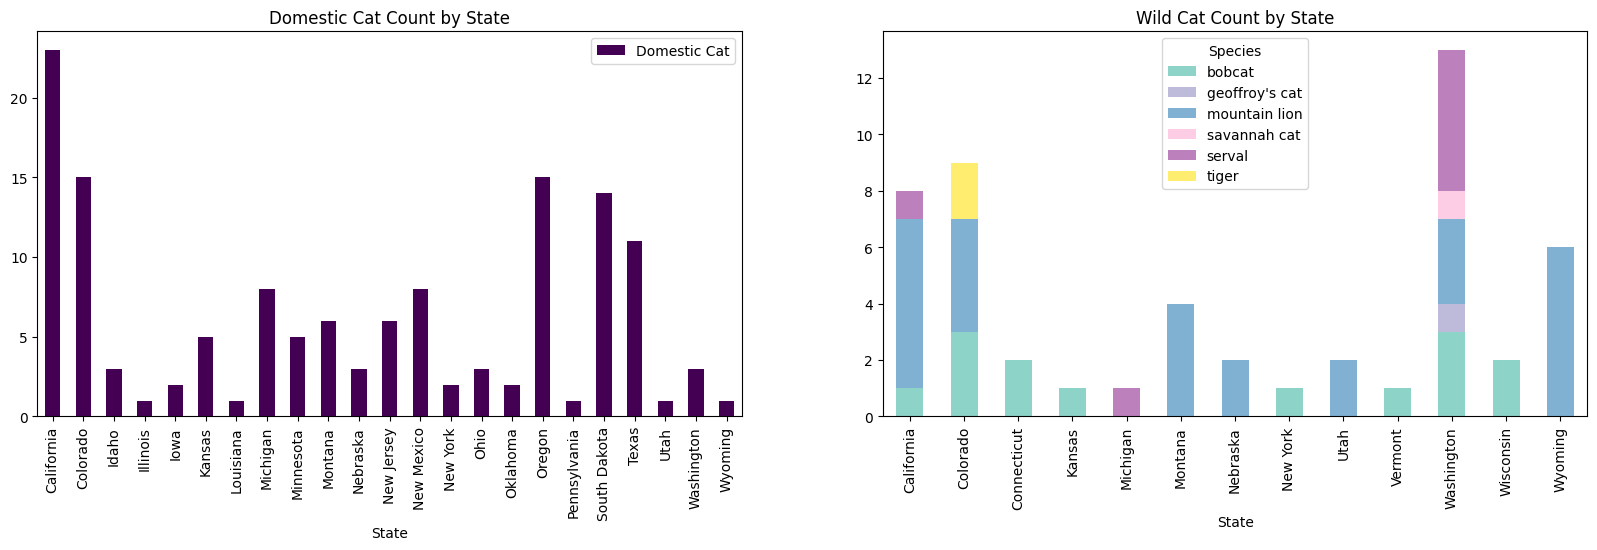

In [ ]:
# Plot detections (ONLY from USDA) as a stacked bar chart where:
# Each bar is a state
# Each plot is a different domestication status of cat (wild/big vs. domesticated cats)



detections_feline["Domestication"] = detections_feline["Species"].apply(lambda x: "domestic" if x == "domestic cat" or x == "cat" else "wild")

detections_feline_trimmed = detections_feline[["State", "Species", "Domestication"]]

# print(detections_feline)

detections_domesticated = detections_feline_trimmed[detections_feline_trimmed["Domestication"] == "domestic"]
detections_domesticated_trimmed = detections_domesticated[["State", "Species"]].groupby(["State"]).count().rename(columns={"Species":"Domestic Cat"})
detections_wild = detections_feline_trimmed[detections_feline_trimmed["Domestication"] == "wild"]
detections_wild_trimmed = pd.pivot_table(detections_wild, index="State", values="Domestication", columns="Species", aggfunc="count", fill_value=0) # .groupby(["State", "Species"]).size()

# print(detections_domesticated_trimmed)
# print(detections_wild_trimmed)

fig, axes = pyplot.subplots(1, 2)

detections_domesticated_trimmed.plot(ax=axes[0], kind="bar", figsize=[20, 5], title="Domestic Cat Count by State", colormap="viridis")
detections_wild_trimmed.plot(ax=axes[1], kind="bar", stacked=True, title="Wild Cat Count by State", colormap="Set3")

fig.savefig("cat_counts_state_usda_06-03-2025.png", bbox_inches="tight")